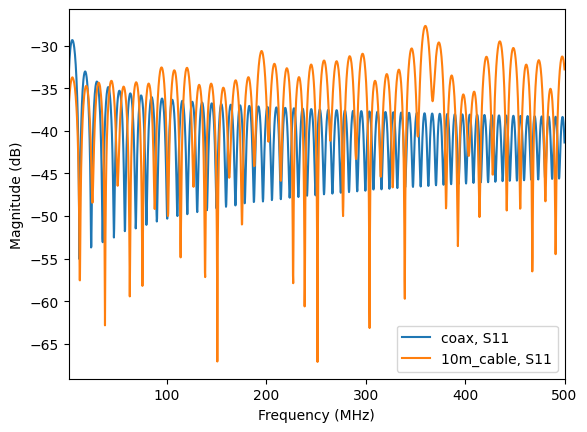

In [12]:
import skrf as rf
import matplotlib.pyplot as plt

from pmrf.models.lines import DatasheetCoaxial
from pmrf.parameter import norm, uniform, fixed
from pmrf.fitting import ScipyFitter

# Create the model
coax = DatasheetCoaxial(name='coax')

# Setup the parameters
parameters = {
    'length': norm(10.0, 2.0),
    'zn': norm(50.0, 2.0),
    'epr': uniform(1.0, 2.0),
    'epr_slope': uniform(0.0, 1.0),
    'k1': uniform(0.0, 10.0),
    'k2': uniform(0.0, 5e-3),
}

# Load the measured data
measured = rf.Network('../examples/data/10m_cable.s2p', f_unit='MHz')

# Initialize the fitter and run the fit
fitter = ScipyFitter(
    model=coax,
    measured=measured,
    params=parameters
)
fitter.fit()

# Plot the results
plt.figure()
fitter.model.to_skrf(measured.frequency).plot_s_db(m=0, n=0)
measured.plot_s_db(m=0, n=0)
plt.savefig('Results.png')